In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from scipy.stats import ttest_ind

import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

import gseapy as gp

import warnings
warnings.filterwarnings("ignore")

plt.style.use("default")
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
import gzip

with gzip.open("GSE33000_series_matrix.txt.gz", "rt") as f:
    lines = f.readlines()

print(f"Total lines: {len(lines)}")
print(lines[:10])

Total lines: 39370
['!Series_title\t"Gene expression profiles of human prefrontal cortex brain tissues"\n', '!Series_geo_accession\t"GSE33000"\n', '!Series_status\t"Public on Jul 31 2014"\n', '!Series_submission_date\t"Oct 14 2011"\n', '!Series_last_update_date\t"Sep 11 2014"\n', '!Series_pubmed_id\t"25080494"\n', '!Series_summary\t"Dissecting the shared etiology of different diseases could benefit from a systematic search for associated molecules and their interactions. We investigated genome-wide disruptions in the co-regulation of genes in two neurodegenerative diseases, Alzheimer\'s or Huntington\'s disease (AD or HD), using expression profiles from postmortem prefrontal cortex samples of 624 demented patients and non-demented control individuals with matched genotype and clinical data. A meta-analysis based screen for changes in coordinate expression patterns revealed differentially co-expressed (DC) gene pairs that either gained or lost correlation in disease cases relative to th

In [3]:
for i, line in enumerate(lines):
    if line.startswith("!Sample_title"):
        print("Sample metadata starts at line:", i)

    if line.startswith("!series_matrix_table_begin"):
        print("Expression matrix starts at line:", i)

Sample metadata starts at line: 40
Expression matrix starts at line: 87


In [4]:
# Extract all sample metadata lines
sample_lines = [line for line in lines if line.startswith("!Sample_")]

# Build a dictionary
metadata = {}

for line in sample_lines:
    parts = line.strip().split("\t")
    field = parts[0].replace("!Sample_", "")
    metadata[field] = [x.strip('"') for x in parts[1:]]

# Convert to DataFrame
meta2 = pd.DataFrame(metadata)

print(meta2.shape)
meta2.head()

(624, 43)


,title,geo_accession,status,submission_date,last_update_date,type,channel_count,source_name_ch1,organism_ch1,characteristics_ch1,...,contact_email,contact_department,contact_institute,contact_address,contact_city,contact_state,contact_zip/postal_code,contact_country,supplementary_file,data_row_count
0,PFC_1,GSM1423780,Public on Jul 31 2014,Jul 01 2014,Jul 31 2014,RNA,2,HBTRC_PF_Pool_1,Homo sapiens,sample type: reference,...,junzhu_99@yahoo.com,Genetics and Genomic Sciences,Icahn Medical School at Mount Sinai,"One Gustave L Levy, Box 1498",New York,NY,10029,USA,NONE,39280
1,PFC_2,GSM1423781,Public on Jul 31 2014,Jul 01 2014,Jul 31 2014,RNA,2,HBTRC_PF_Pool_2,Homo sapiens,sample type: reference,...,junzhu_99@yahoo.com,Genetics and Genomic Sciences,Icahn Medical School at Mount Sinai,"One Gustave L Levy, Box 1498",New York,NY,10029,USA,NONE,39280
2,PFC_3,GSM1423782,Public on Jul 31 2014,Jul 01 2014,Jul 31 2014,RNA,2,HBTRC_PF_Pool_3,Homo sapiens,sample type: reference,...,junzhu_99@yahoo.com,Genetics and Genomic Sciences,Icahn Medical School at Mount Sinai,"One Gustave L Levy, Box 1498",New York,NY,10029,USA,NONE,39280
3,PFC_4,GSM1423783,Public on Jul 31 2014,Jul 01 2014,Jul 31 2014,RNA,2,HBTRC_PF_Pool_4,Homo sapiens,sample type: reference,...,junzhu_99@yahoo.com,Genetics and Genomic Sciences,Icahn Medical School at Mount Sinai,"One Gustave L Levy, Box 1498",New York,NY,10029,USA,NONE,39280
4,PFC_5,GSM1423784,Public on Jul 31 2014,Jul 01 2014,Jul 31 2014,RNA,2,HBTRC_PF_Pool_5,Homo sapiens,sample type: reference,...,junzhu_99@yahoo.com,Genetics and Genomic Sciences,Icahn Medical School at Mount Sinai,"One Gustave L Levy, Box 1498",New York,NY,10029,USA,NONE,39280


In [6]:
for col in meta2.columns:
    if "characteristics" in col:
        print("="*80)
        print(col)
        print(meta2[col].head(10))

characteristics_ch1
0    sample type: reference
1    sample type: reference
2    sample type: reference
3    sample type: reference
4    sample type: reference
5    sample type: reference
6    sample type: reference
7    sample type: reference
8    sample type: reference
9    sample type: reference
Name: characteristics_ch1, dtype: object
characteristics_ch2
0    disease status: Alzheimer's disease
1    disease status: Alzheimer's disease
2    disease status: Alzheimer's disease
3    disease status: Alzheimer's disease
4    disease status: Alzheimer's disease
5    disease status: Alzheimer's disease
6    disease status: Alzheimer's disease
7    disease status: Alzheimer's disease
8    disease status: Alzheimer's disease
9    disease status: Alzheimer's disease
Name: characteristics_ch2, dtype: object


In [7]:
meta2[["title", "characteristics_ch2"]].head(30)

,title,characteristics_ch2
0,PFC_1,disease status: Alzheimer's disease
1,PFC_2,disease status: Alzheimer's disease
2,PFC_3,disease status: Alzheimer's disease
3,PFC_4,disease status: Alzheimer's disease
4,PFC_5,disease status: Alzheimer's disease
5,PFC_6,disease status: Alzheimer's disease
6,PFC_7,disease status: Alzheimer's disease
7,PFC_8,disease status: Alzheimer's disease
8,PFC_9,disease status: Alzheimer's disease
9,PFC_10,disease status: Alzheimer's disease


In [8]:
meta2["characteristics_ch2"].value_counts().head(20)

characteristics_ch2
disease status: Alzheimer's disease     310
disease status: non-demented            157
disease status: Huntington's disease    157
Name: count, dtype: int64

In [9]:
meta2_clean = pd.DataFrame()

meta2_clean["Sample_ID"] = meta2["geo_accession"]

meta2_clean["Diagnosis"] = (
    meta2["characteristics_ch2"]
    .str.replace("disease status: ", "", regex=False)
)

meta2_clean["Title"] = meta2["title"]

# Keep only AD and Controls
meta2_clean = meta2_clean[
    meta2_clean["Diagnosis"].isin(
        ["Alzheimer's disease", "non-demented"]
    )
].copy()

# Rename control group
meta2_clean["Diagnosis"] = (
    meta2_clean["Diagnosis"]
    .replace({"non-demented": "Control"})
)

print(meta2_clean.shape)
print()

print(meta2_clean["Diagnosis"].value_counts())

meta2_clean.head()

(467, 3)

Diagnosis
Alzheimer's disease    310
Control                157
Name: count, dtype: int64


,Sample_ID,Diagnosis,Title
0,GSM1423780,Alzheimer's disease,PFC_1
1,GSM1423781,Alzheimer's disease,PFC_2
2,GSM1423782,Alzheimer's disease,PFC_3
3,GSM1423783,Alzheimer's disease,PFC_4
4,GSM1423784,Alzheimer's disease,PFC_5


In [10]:
# Find where the expression table starts
start = None
end = None

for i, line in enumerate(lines):
    if line.startswith("!series_matrix_table_begin"):
        start = i + 1
    if line.startswith("!series_matrix_table_end"):
        end = i

print(start, end)

88 39369


In [11]:
from io import StringIO

expr2 = pd.read_csv(
    StringIO("".join(lines[start:end])),
    sep="\t"
)

print(expr2.shape)

expr2.head()

(39280, 625)


,ID_REF,GSM1423780,GSM1423781,GSM1423782,GSM1423783,GSM1423784,GSM1423785,GSM1423786,GSM1423787,GSM1423788,...,GSM1424394,GSM1424395,GSM1424396,GSM1424397,GSM1424398,GSM1424399,GSM1424400,GSM1424401,GSM1424402,GSM1424403
0,10019475365,-0.016184,0.027599,-0.089661,-0.020493,-0.051699,0.075485,-0.046606,0.111980,0.018505,...,0.0844,0.1040,0.2140,0.00285,0.0945,0.1220,-0.0258,0.0186,0.14300,0.1600
1,10019481149,-0.017105,-0.023574,0.044863,0.003438,-0.064108,-0.053226,-0.071823,-0.051699,-0.024906,...,0.0409,0.0761,0.0633,0.03090,0.0319,0.0390,0.0897,0.1160,-0.00317,0.0359
2,10019495284,0.077440,-0.058746,-0.120759,0.072692,-0.051002,-0.183919,-0.074997,-0.090709,0.049640,...,-0.1360,-0.0547,-0.1920,-0.11200,-0.1230,-0.1520,0.5390,0.2280,-0.02580,-0.0968
3,10019687586,0.033595,0.032914,-0.030928,-0.033051,-0.049156,-0.011204,0.072451,0.126576,0.078031,...,-0.0120,0.0533,-0.0416,-0.01530,0.0483,0.0127,0.0419,0.1290,0.00619,-0.0360
4,10019713746,-0.001819,0.032487,-0.015073,-0.010303,0.063070,0.113860,-0.055590,0.127236,0.056135,...,0.1140,0.0270,0.2590,0.10100,0.2000,0.1170,-0.0359,0.0833,0.19500,0.1530


In [15]:
import gzip

with gzip.open("GPL4372.annot.gz", "rt") as f:
    gpl_lines = f.readlines()

for i, line in enumerate(gpl_lines):
    if line.startswith("ID\t"):
        print("Annotation starts at line:", i)
        break

Annotation starts at line: 27


In [16]:
from io import StringIO

gpl2 = pd.read_csv(
    StringIO("".join(gpl_lines[27:])),   # <-- replace 34 with YOUR number
    sep="\t"
)

print(gpl2.shape)

gpl2.head()

(39303, 21)


,ID,Gene title,Gene symbol,Gene ID,UniGene title,UniGene symbol,UniGene ID,Nucleotide Title,GI,GenBank Accession,...,Platform_ORF,Platform_SPOTID,Chromosome location,Chromosome annotation,GO:Function,GO:Process,GO:Component,GO:Function ID,GO:Process ID,GO:Component ID
0,10025930146,NaN,NaN,NaN,Transcribed locus,NaN,Hs.570225,om25h03.s1 Soares_NFL_T_GBC_S1 Homo sapiens cD...,3075810.0,AA926913,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10025930335,"xeroderma pigmentosum, complementation group A",XPA,7507,"Xeroderma pigmentosum, complementation group A",XPA,Hs.654364,"Homo sapiens cDNA FLJ11599 fis, clone HEMBA100...",10432891.0,AK021661,...,NaN,NaN,9q22.3,"Chromosome 9, NC_000009.10 (99477012..99499460...",damaged DNA binding///metal ion binding///nucl...,nucleotide-excision repair,nucleus,GO:0003684///GO:0046872///GO:0000166///GO:0005...,GO:0006289,GO:0005634
2,10025913794,hypothetical gene supported by NM_194304,LOC439911,439911,NaN,NaN,NaN,Homo sapiens mRNA; cDNA DKFZp313L1514 (from cl...,21732601.0,AL832060,...,NaN,NaN,10q11.21,Chromosome 10,NaN,NaN,NaN,NaN,NaN,NaN
3,10023807248,solute carrier family 35 (UDP-N-acetylglucosam...,SLC35A3,23443,NaN,NaN,NaN,Homo sapiens solute carrier family 35 (UDP-N-a...,6912667.0,NM_012243,...,SLC35A3,NaN,1p21,"Chromosome 1, NC_000001.9 (100208128..100261594)",UDP-N-acetylglucosamine transmembrane transpor...,UDP-N-acetylglucosamine metabolic process///UD...,Golgi apparatus///Golgi membrane///integral to...,GO:0005462///GO:0005338///GO:0005351,GO:0006047///GO:0015788///GO:0015780,GO:0005794///GO:0000139///GO:0016021///GO:0016020
4,10023809851,katanin p60 subunit A-like 1,KATNAL1,84056,NaN,NaN,NaN,Homo sapiens katanin p60 subunit A-like 1 (KAT...,62177111.0,NM_001014380,...,KATNAL1,NaN,13q12.3,"Chromosome 13, NC_000013.9 (29674767..29779584...",ATP binding///hydrolase activity///microtubule...,NaN,microtubule,GO:0005524///GO:0016787///GO:0008568///GO:0017...,NaN,GO:0005874


In [19]:
gpl2 = gpl2[["ID", "Gene symbol"]].copy()

gpl2 = gpl2.rename(columns={
    "ID": "ID_REF",
    "Gene symbol": "GeneSymbol"
})

print(gpl2.head())

        ID_REF GeneSymbol
0  10025930146        NaN
1  10025930335        XPA
2  10025913794  LOC439911
3  10023807248    SLC35A3
4  10023809851    KATNAL1


In [20]:
expr2 = expr2.merge(
    gpl2,
    on="ID_REF",
    how="left"
)

print(expr2.shape)

expr2.head()

(39280, 626)


,ID_REF,GSM1423780,GSM1423781,GSM1423782,GSM1423783,GSM1423784,GSM1423785,GSM1423786,GSM1423787,GSM1423788,...,GSM1424395,GSM1424396,GSM1424397,GSM1424398,GSM1424399,GSM1424400,GSM1424401,GSM1424402,GSM1424403,GeneSymbol
0,10019475365,-0.016184,0.027599,-0.089661,-0.020493,-0.051699,0.075485,-0.046606,0.111980,0.018505,...,0.1040,0.2140,0.00285,0.0945,0.1220,-0.0258,0.0186,0.14300,0.1600,NaN
1,10019481149,-0.017105,-0.023574,0.044863,0.003438,-0.064108,-0.053226,-0.071823,-0.051699,-0.024906,...,0.0761,0.0633,0.03090,0.0319,0.0390,0.0897,0.1160,-0.00317,0.0359,NaN
2,10019495284,0.077440,-0.058746,-0.120759,0.072692,-0.051002,-0.183919,-0.074997,-0.090709,0.049640,...,-0.0547,-0.1920,-0.11200,-0.1230,-0.1520,0.5390,0.2280,-0.02580,-0.0968,NaN
3,10019687586,0.033595,0.032914,-0.030928,-0.033051,-0.049156,-0.011204,0.072451,0.126576,0.078031,...,0.0533,-0.0416,-0.01530,0.0483,0.0127,0.0419,0.1290,0.00619,-0.0360,NaN
4,10019713746,-0.001819,0.032487,-0.015073,-0.010303,0.063070,0.113860,-0.055590,0.127236,0.056135,...,0.0270,0.2590,0.10100,0.2000,0.1170,-0.0359,0.0833,0.19500,0.1530,NaN


In [21]:
expr2 = (
    expr2
    .groupby("GeneSymbol")
    .mean(numeric_only=True)
)

print(expr2.shape)

expr2.head()

(16818, 624)


,GSM1423780,GSM1423781,GSM1423782,GSM1423783,GSM1423784,GSM1423785,GSM1423786,GSM1423787,GSM1423788,GSM1423789,...,GSM1424394,GSM1424395,GSM1424396,GSM1424397,GSM1424398,GSM1424399,GSM1424400,GSM1424401,GSM1424402,GSM1424403
GeneSymbol,,,,,,,,,,,,,,,,,,,,,
2'-PDE,0.019851,0.019361,-0.018256,-0.050415,-0.077144,-0.048854,0.091725,-0.040648,0.032958,-0.026334,...,0.060300,0.009860,0.007390,0.078900,-0.035800,-0.113000,0.129000,-0.044300,0.024400,-0.091100
3.8-1,0.010544,-0.009350,-0.038474,0.086230,-0.013454,0.045203,0.099071,0.183700,-0.051606,0.065064,...,0.017300,-0.156000,-0.096100,-0.178000,-0.175000,-0.014000,-0.149000,-0.216000,-0.188000,-0.025500
7A5,0.023529,0.019025,0.005112,-0.020732,-0.045510,0.057970,0.017385,-0.001099,-0.048202,0.045314,...,0.066733,-0.026533,0.022203,0.025567,-0.057633,0.027833,-0.032167,0.021667,-0.024267,-0.029067
A1BG,-0.057843,0.086924,0.067764,-0.016819,-0.143307,-0.127444,-0.131572,-0.109074,-0.077973,-0.032615,...,-0.007010,0.032800,0.006660,0.007720,-0.017300,0.010500,0.000073,0.033800,-0.018900,-0.151000
A2BP1,0.064200,0.047771,0.208575,-0.011465,0.058914,-0.448718,-0.361347,-0.881874,-0.000092,-0.434787,...,-0.748000,-0.161000,-0.131000,-0.026000,-0.131000,-0.228000,-0.151000,-0.168000,-0.226000,-0.121000


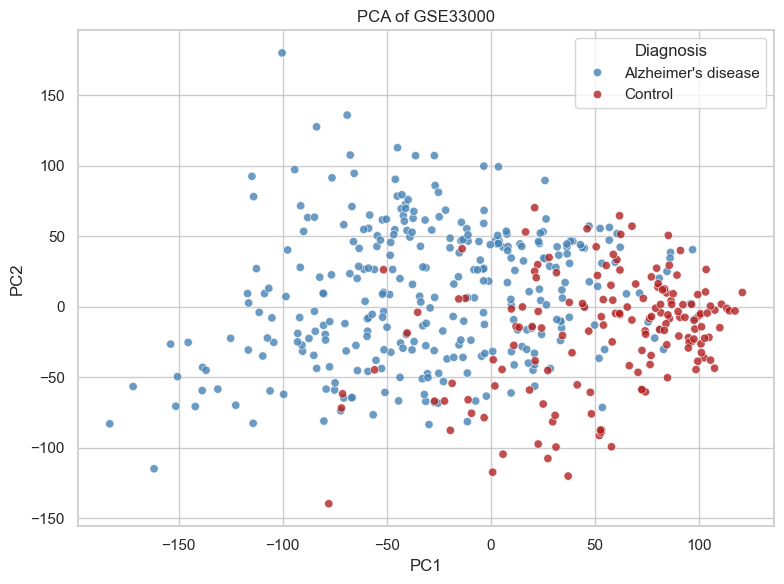

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = expr2.T

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)

pcs = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": pcs[:,0],
    "PC2": pcs[:,1],
    "Diagnosis": meta2_clean["Diagnosis"].values
})

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Diagnosis",
    palette=["steelblue","firebrick"],
    alpha=0.8
)

plt.title("PCA of GSE33000")

plt.tight_layout()

plt.savefig("Figure1_PCA_GSE33000.png", dpi=300)

plt.show()

In [28]:
# Remove genes containing missing values
expr2 = expr2.dropna(axis=0)

print(expr2.shape)
print("Remaining NaNs:", expr2.isna().sum().sum())

(16664, 467)
Remaining NaNs: 0


In [30]:
# Split samples
ad_samples2 = meta2_clean.loc[
    meta2_clean["Diagnosis"] == "Alzheimer's disease",
    "Sample_ID"
]

ctrl_samples2 = meta2_clean.loc[
    meta2_clean["Diagnosis"] == "Control",
    "Sample_ID"
]

expr_ad2 = expr2[ad_samples2]
expr_ctrl2 = expr2[ctrl_samples2]

print(expr_ad2.shape)
print(expr_ctrl2.shape)

(16664, 310)
(16664, 157)


In [31]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import numpy as np

# Mean expression
mean_ad = expr_ad2.mean(axis=1)
mean_ctrl = expr_ctrl2.mean(axis=1)

# Log2 Fold Change
logFC = mean_ad - mean_ctrl

# Welch t-test
pvals = []

for gene in expr2.index:
    _, p = ttest_ind(
        expr_ad2.loc[gene],
        expr_ctrl2.loc[gene],
        equal_var=False,
        nan_policy="omit"
    )
    pvals.append(p)

# FDR correction
adj = multipletests(
    pvals,
    method="fdr_bh"
)[1]

# DEG table
deg2 = pd.DataFrame({
    "logFC": logFC,
    "P.Value": pvals,
    "adj.P.Val": adj
}, index=expr2.index)

deg2 = deg2.sort_values("adj.P.Val")

print(deg2.shape)

deg2.head()

(16664, 3)


,logFC,P.Value,adj.P.Val
GeneSymbol,,,
NRN1,-0.340629,1.877512e-82,3.128686e-78
NEUROD6,-0.505063,4.354395e-82,3.628082e-78
PPEF1,-0.636033,2.678691e-79,1.487924e-75
SVOP,-0.384524,9.946951e-78,4.143900e-74
GNRH1,0.196247,2.832906e-77,9.441510e-74


In [36]:
sig2 = deg2[
    (deg2["adj.P.Val"] < 0.05) &
    (abs(deg2["logFC"]) > 0.30)
]

print(sig2.shape)
sig2.head()

(320, 3)


,logFC,P.Value,adj.P.Val
GeneSymbol,,,
NRN1,-0.340629,1.877512e-82,3.128686e-78
NEUROD6,-0.505063,4.354395e-82,3.628082e-78
PPEF1,-0.636033,2.678691e-79,1.487924e-75
SVOP,-0.384524,9.946951e-78,4.143900e-74
BDNF,-0.450985,2.344805e-74,3.552166e-71


In [37]:
sig2.shape

(320, 3)

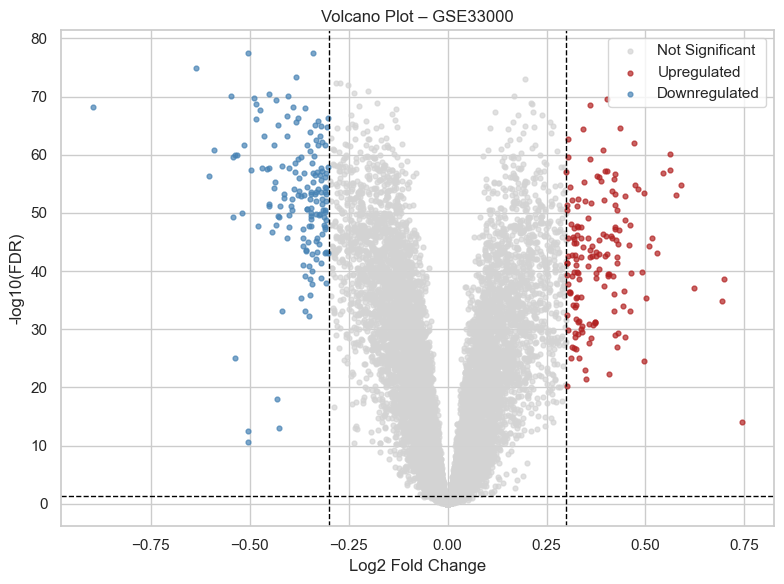

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Copy DEG table
volcano2 = deg2.copy()

# Calculate -log10(FDR)
volcano2["-log10(FDR)"] = -np.log10(volcano2["adj.P.Val"] + 1e-300)

# Categorize genes
volcano2["Status"] = "Not Significant"

volcano2.loc[
    (volcano2["adj.P.Val"] < 0.05) &
    (volcano2["logFC"] > 0.30),
    "Status"
] = "Upregulated"

volcano2.loc[
    (volcano2["adj.P.Val"] < 0.05) &
    (volcano2["logFC"] < -0.30),
    "Status"
] = "Downregulated"

# Plot
plt.figure(figsize=(8,6))

colors = {
    "Not Significant":"lightgray",
    "Upregulated":"firebrick",
    "Downregulated":"steelblue"
}

for status, color in colors.items():
    subset = volcano2[volcano2["Status"] == status]
    plt.scatter(
        subset["logFC"],
        subset["-log10(FDR)"],
        s=12,
        c=color,
        alpha=0.7,
        label=status
    )

plt.axvline(0.30, color="black", linestyle="--", linewidth=1)
plt.axvline(-0.30, color="black", linestyle="--", linewidth=1)
plt.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=1)

plt.xlabel("Log2 Fold Change")
plt.ylabel("-log10(FDR)")
plt.title("Volcano Plot – GSE33000")

plt.legend()

plt.tight_layout()

plt.savefig("Figure2_Volcano_GSE33000.png", dpi=300)

plt.show()

In [39]:
# Top 50 DEGs by adjusted p-value
top50_2 = sig2.sort_values("adj.P.Val").head(50)

print(top50_2.shape)

top50_2.head()

(50, 3)


,logFC,P.Value,adj.P.Val
GeneSymbol,,,
NRN1,-0.340629,1.877512e-82,3.128686e-78
NEUROD6,-0.505063,4.354395e-82,3.628082e-78
PPEF1,-0.636033,2.678691e-79,1.487924e-75
SVOP,-0.384524,9.946951e-78,4.143900e-74
BDNF,-0.450985,2.344805e-74,3.552166e-71


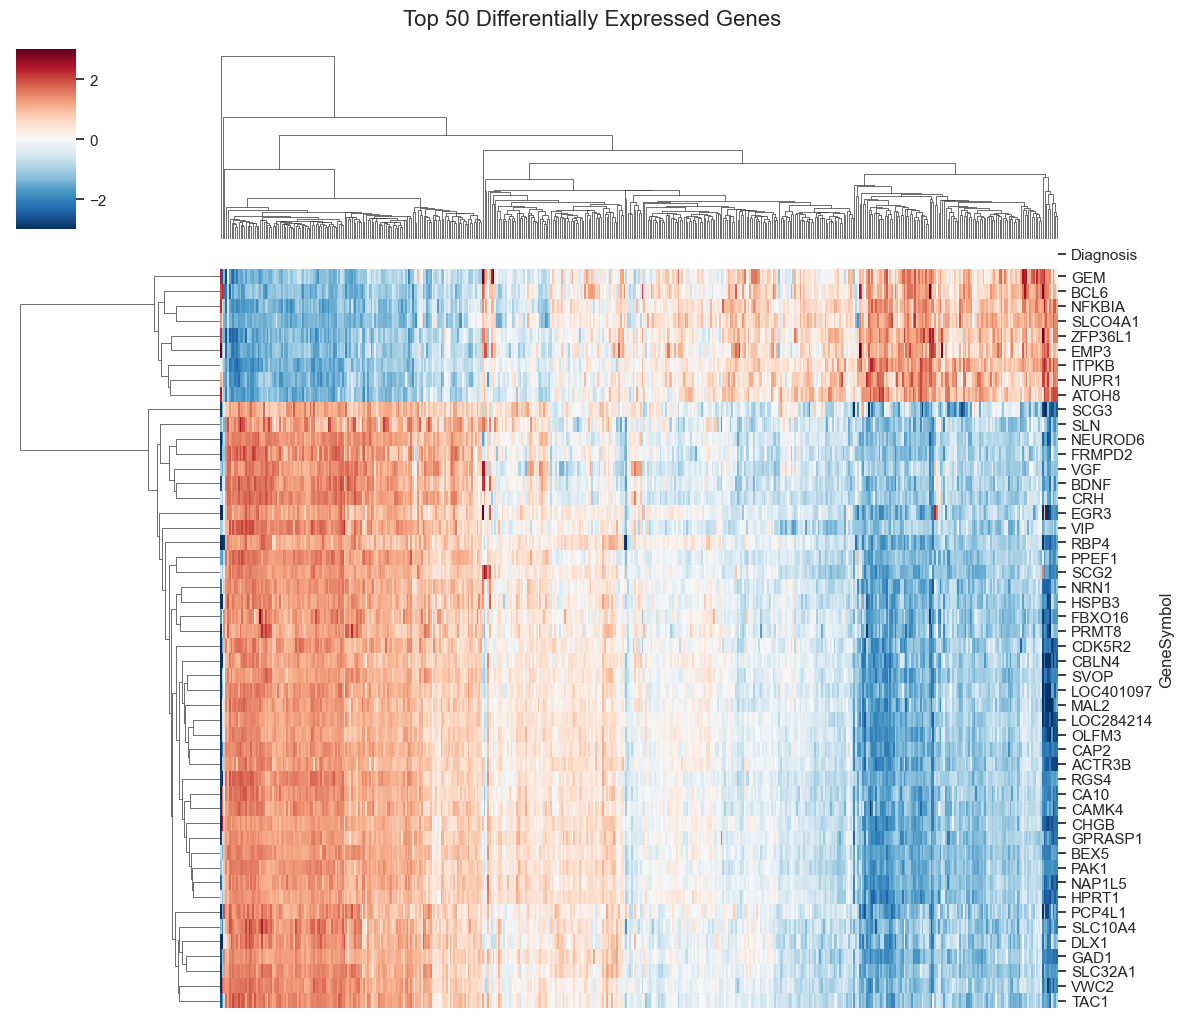

In [46]:
g = sns.clustermap(
    heatmap2_z,
    cmap="RdBu_r",
    center=0,
    vmin=-3,
    vmax=3,
    figsize=(12,10),
    xticklabels=False,
    yticklabels=True,
    col_colors=sample_colors
)

g.fig.suptitle(
    "Top 50 Differentially Expressed Genes",
    fontsize=16,
    y=1.02
)

plt.savefig(
    "Figure3_Heatmap_GSE33000.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
heatmap2.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
GSM1423780,50.0,-0.064487,0.133344,-0.640795,-0.140242,-0.054422,0.027952,0.185086
GSM1423781,50.0,-0.023399,0.120842,-0.502130,-0.078633,0.002641,0.046119,0.204303
GSM1423782,50.0,0.103075,0.223279,-0.584709,0.123696,0.181764,0.232863,0.326574
GSM1423783,50.0,-0.041114,0.127167,-0.358886,-0.118450,-0.047835,0.008984,0.418480
GSM1423784,50.0,-0.070130,0.153431,-0.417276,-0.147339,-0.041156,0.044482,0.165655


In [44]:
print(heatmap2_z.min().min())
print(heatmap2_z.max().max())

-6.026750744269577
3.590221445192611


In [45]:
print(heatmap2.min().min(), heatmap2.max().max())
print(heatmap2_z.min().min(), heatmap2_z.max().max())

-1.824551 1.0503870000000002
-6.026750744269577 3.590221445192611


In [47]:
heatmap2_z.iloc[:5, :10]

,GSM1423780,GSM1423781,GSM1423782,GSM1423783,GSM1423784,GSM1423785,GSM1423786,GSM1423787,GSM1423788,GSM1423789
GeneSymbol,,,,,,,,,,
NRN1,0.615383,0.722902,1.280614,1.011712,0.980942,-0.430687,-1.118927,-1.953733,0.574062,-0.917546
NEUROD6,-0.028710,0.835898,1.079987,0.645910,0.844964,-0.827713,-0.680272,-1.888122,0.199519,-0.813654
PPEF1,0.788406,0.833414,1.343617,0.662815,0.809733,-0.805129,-0.796820,-1.476722,0.363369,-0.725797
SVOP,0.437502,0.746199,1.131673,0.327321,0.569838,-0.942278,-1.006389,-2.157360,0.587554,-0.678423
BDNF,0.181689,0.116645,1.285687,0.405077,0.278745,-0.739405,-0.580163,-1.624759,0.208582,-0.869018


In [48]:
import os

os.makedirs("Results/Dataset2", exist_ok=True)
os.makedirs("Figures/Dataset2", exist_ok=True)

deg2.to_csv(
    "Results/Dataset2/GSE33000_DEGs.csv"
)

sig2.to_csv(
    "Results/Dataset2/GSE33000_Significant_DEGs.csv"
)

print("Dataset 2 tables saved.")

Dataset 2 tables saved.
